# TP2 CFD
# Mathys PRIMA - Ugo NOWAK groupe TP4

## 1. Description du problème

### Équation de convection-diffusion

$$
\frac{\partial \phi}{\partial t} + \nabla \cdot (\vec{u}\, \phi) = \nabla \cdot (\Gamma \nabla \phi)
$$

avec **terme convectif** :

$$
\frac{\partial \phi}{\partial t} + \nabla \cdot (\vec{u}\, \phi)
$$

et **terme diffusif** :

$$
\nabla \cdot (\Gamma \nabla \phi)
$$

### Développement en 2D

$$
\frac{\partial \phi}{\partial t}
+ \frac{\partial u}{\partial x}\phi
+ \frac{\partial v}{\partial y}\phi
= \frac{\partial}{\partial x}\!\left[\Gamma \frac{\partial \phi}{\partial x}\right]
+ \frac{\partial}{\partial y}\!\left[\Gamma \frac{\partial \phi}{\partial y}\right]
$$

avec $\vec{u} = \begin{pmatrix} u \\ v \end{pmatrix}$ et on se place à l'ordre 2.

### Formulation intégrale sur un volume de contrôle $V_{ij}$

Écrivons la formulation intégrale de cette EDP sur un volume de contrôle $V_{ij}$ :

$$
\int_{V_{ij}} \left(
  \frac{\partial \phi}{\partial t}
  + \frac{\partial u\phi}{\partial x}
  + \frac{\partial v\phi}{\partial y}
\right) dV
= \int_{V_{ij}} \left(
  \frac{\partial}{\partial x}\!\left[\Gamma \frac{\partial \phi}{\partial x}\right]
  + \frac{\partial}{\partial y}\!\left[\Gamma \frac{\partial \phi}{\partial y}\right]
\right) dV
$$

avec $dV = h\, dx\, dy$.

On sépare le terme instationnaire avec le terme convectif :

$$
\int_{V_{ij}} \frac{\partial \phi}{\partial t}\, dV
+ \int_{V_{ij}} \left(
  \frac{\partial u\phi}{\partial x} + \frac{\partial v\phi}{\partial y}
\right) dV
= \int_{V_{ij}} \left(
  \frac{\partial}{\partial x}\!\left[\Gamma \frac{\partial \phi}{\partial x}\right]
  + \frac{\partial}{\partial y}\!\left[\Gamma \frac{\partial \phi}{\partial y}\right]
\right) dV
$$

### Interpolation du terme instationnaire

Par le **théorème de la moyenne** on a :

$$
\left.\frac{\partial \phi}{\partial t}\right|_{ij}
= \frac{1}{V_{ij}} \int_{V_{ij}} \frac{\partial \phi}{\partial t}\, dV
$$

$$
\Rightarrow \int_{V_{ij}} \frac{\partial \phi}{\partial t}\, dV
= V_{ij} \left.\frac{\partial \phi}{\partial t}\right|_{ij}
\qquad \text{avec } V_{ij} = h\,\Delta x\,\Delta y
$$

### Interpolation différentiel à l'ordre 1 temporel

$$
\left.\frac{\partial \phi}{\partial t}\right|_{ij}
= \frac{\phi_{ij}^{n+1} - \phi_{ij}^{n}}{\Delta t}
$$

$$
\Rightarrow \int_{V_{ij}} \frac{\partial \phi}{\partial t}\, dV
= h\,\Delta x\,\Delta y\left(
  \frac{\phi_{ij}^{n+1} - \phi_{ij}^{n}}{\Delta t}
\right)
$$

### Terme diffusif

$$
\int_{x_{i-1/2}}^{x_{i+1/2}} \int_{y_{j-1/2}}^{y_{j+1/2}}
\left(
  \frac{\partial}{\partial x}\!\left[\Gamma \frac{\partial \phi}{\partial x}\right]
  + \frac{\partial}{\partial y}\!\left[\Gamma \frac{\partial \phi}{\partial y}\right]
\right) h\, dx\, dy
$$

$$
= h\left[
  \int_{x_{i-1/2}}^{x_{i+1/2}} \int_{y_{j-1/2}}^{y_{j+1/2}}
  \frac{\partial}{\partial x}\!\left[\Gamma \frac{\partial \phi}{\partial x}\right] dx\, dy
  + \int_{x_{i+1/2}}^{x_{i+1/2}} \int_{y_{j-1/2}}^{y_{j+1/2}}
  \frac{\partial}{\partial y}\!\left[\Gamma \frac{\partial \phi}{\partial y}\right] dx\, dy
\right]
$$

$$
= h\,\Delta y \left[\Gamma \frac{\partial \phi}{\partial x}\right]_{x_{i-1/2}}^{x_{i+1/2}}
+ h\,\Delta x \left[\Gamma \frac{\partial \phi}{\partial y}\right]_{y_{j-1/2}}^{y_{j+1/2}}
$$

$$
= h\,\Delta y\,\Gamma\left[
  \left.\frac{\partial \phi}{\partial x}\right|_{i+\frac{1}{2},j}
  - \left.\frac{\partial \phi}{\partial x}\right|_{i-\frac{1}{2},j}
\right]
+ h\,\Delta x\,\Gamma\left[
  \left.\frac{\partial \phi}{\partial y}\right|_{i,j+\frac{1}{2}}
  - \left.\frac{\partial \phi}{\partial y}\right|_{i,j-\frac{1}{2}}
\right]
$$

### Approximation des dérivées aux faces (ordre 2)

$$
\left.\frac{\partial \phi}{\partial x}\right|_{i+\frac{1}{2},j}
= \frac{\phi_{i+1,j} - \phi_{i,j}}{2\,\dfrac{\Delta x}{2}}
+ \mathcal{O}(\Delta x^2)
$$

$$
\left.\frac{\partial \phi}{\partial x}\right|_{i-\frac{1}{2},j}
= \frac{\phi_{i,j} - \phi_{i-1,j}}{2\,\dfrac{\Delta x}{2}}
+ \mathcal{O}(\Delta x^2)
$$

$$
\left.\frac{\partial \phi}{\partial y}\right|_{i,j+\frac{1}{2}}
= \frac{\phi_{i,j+1} - \phi_{i,j}}{2\,\dfrac{\Delta x}{2}}
+ \mathcal{O}(\Delta y^2)
$$

$$
\left.\frac{\partial \phi}{\partial y}\right|_{i,j-\frac{1}{2}}
= \frac{\phi_{i,j} - \phi_{i,j-1}}{2\,\dfrac{\Delta y}{2}}
+ \mathcal{O}(\Delta y^2)
$$

### Terme diffusif assemblé

$$
\Rightarrow
h\,\frac{\Delta y}{\Delta x}\,\Gamma\left[\phi_{i+1,j} - 2\phi_{i,j} + \phi_{i-1,j}\right]
+ h\,\frac{\Delta x}{\Delta y}\,\Gamma\left[\phi_{i,j+1} - 2\phi_{i,j} + \phi_{i,j-1}\right]
$$

### Terme convectif

$$
\int_{x_{i-1/2}}^{x_{i+1/2}} \int_{y_{j-1/2}}^{y_{j+1/2}}
\left(
  \frac{\partial u\phi}{\partial x} + \frac{\partial v\phi}{\partial y}
\right) h\, dx\, dy
$$

$$
= h\left[
  \int_{x_{i-1/2}}^{x_{i+1/2}} \int_{y_{j-1/2}}^{y_{j+1/2}}
  \frac{\partial u\phi}{\partial x}\, dx\, dy
  + \int_{x_{i-1/2}}^{x_{i+1/2}} \int_{y_{j-1/2}}^{y_{j+1/2}}
  \frac{\partial v\phi}{\partial y}\, dx\, dy
\right]
$$

$$
= h\left[
  \Delta y\, u\left[\phi\right]_{x_{i-1/2}}^{x_{i+1/2}}
  + \Delta x\, v\left[\phi\right]_{y_{j-1/2}}^{y_{j+1/2}}
\right]
$$

$$
= h\left[
  \Delta y\, u\left(\phi_{i+\frac{1}{2},j} - \phi_{i-\frac{1}{2},j}\right)
  + \Delta x\, v\left(\phi_{i,j+\frac{1}{2}} - \phi_{i,j-\frac{1}{2}}\right)
\right]
$$

### Interpolation upwind à l'ordre 1

$$
\phi_{i+\frac{1}{2},j} = \phi_{i,j}, \quad
\phi_{i-\frac{1}{2},j} = \phi_{i-1,j}, \quad
\phi_{i,j+\frac{1}{2}} = \phi_{i,j}, \quad
\phi_{i,j-\frac{1}{2}} = \phi_{i,j-1}
$$

$$
\Rightarrow
h\left[
  \Delta y\, u\left(\phi_{i,j} - \phi_{i-1,j}\right)
  + \Delta x\, v\left(\phi_{i,j} - \phi_{i,j-1}\right)
\right]
$$

### EDP discrétisée complète

En assemblant tous les termes dans l'EDP :

$$
h\,\frac{\Delta x\,\Delta y}{\Delta t}\left(\phi_{ij}^{n+1} - \phi_{ij}^{n}\right)
+ h\,\Delta y\, u\left(\phi_{i,j} - \phi_{i-1,j}\right)
+ h\,\Delta x\, v\left(\phi_{i,j} - \phi_{i,j-1}\right)
=
$$

$$
h\,\frac{\Delta y}{\Delta x}\,\Gamma\left[\phi_{i+1,j} - 2\phi_{i,j} + \phi_{i-1,j}\right]
+ h\,\frac{\Delta x}{\Delta y}\,\Gamma\left[\phi_{i,j+1} - 2\phi_{i,j} + \phi_{i,j-1}\right]
$$

### Schéma explicite — expression de $\phi_{ij}^{n+1}$

$$
\Rightarrow \phi_{ij}^{n+1} = \phi_{ij}
+ \frac{\Delta t}{\Delta x\,\Delta y}\left[
  -a_{ij}\,\phi_{ij}
  + a_{i-1,j}\,\phi_{i-1,j}
  + a_{i+1,j}\,\phi_{i+1,j}
  + a_{i,j-1}\,\phi_{i,j-1}
  + a_{i,j+1}\,\phi_{i,j+1}
\right]
$$

avec :

### Expressions des coefficients $a$

$$
a_{i+1,j} = \Gamma\,\frac{\Delta y}{\Delta x}
$$

$$
a_{i-1,j} = \Gamma\,\frac{\Delta y}{\Delta x} + u\,\Delta y
$$

$$
a_{i,j+1} = \Gamma\,\frac{\Delta x}{\Delta y}
$$

$$
a_{i,j-1} = \Gamma\,\frac{\Delta x}{\Delta y} + v\,\Delta x
$$

$$
a_{i,j} = 2\Gamma\,\frac{\Delta y}{\Delta x} + 2\Gamma\,\frac{\Delta x}{\Delta y} + u\,\Delta y + v\,\Delta x
$$

## 2. Ecriture du problème en 2D

In [10]:
import numpy  as np
import matplotlib.pyplot as plt

def resolution_phi (Lx, Ly, Nx, Ny, gamma, phi0, t, U0, V0, x0, y0, D):
    
    # Création du maillage
    # Discrétisation uniforme du domaine [0, Lx] x [0, Ly] en Nx+1 et Ny+1 points
    x = np.linspace(0,Lx,Nx+1) # Distribution des centres de cellules suivant x
    y = np.linspace(0,Ly,Ny+1) # Distribution des centres de cellules suivant y
    dx = x[1] - x[0] # Taille des cellules suivant x
    dy = y[1] - y[0] # Taille des cellules suivant y

    # Calucul du pas de temps
    # Pour un schéma explicite, le pas de temps doit satisfaire simultanément
    # la condition CFL convective (dx/U0) et la condition de stabilité diffusive
    # On prend la moitié du minimum des deux pour garantir la stabilité
    if dx/U0 <= (dx**2*dy**2)/(2*gamma*(dx**2+dy**2)):
        dt = dx/(2*U0)
    else:
        dt = (dx**2*dy**2)/(4*gamma*(dx**2+dy**2))
        
    # Nombre total d'itérations temporelles nécessaires pour atteindre le temps t
    N = int(t/dt)
    
    # Initialisation des champs
    # Champ de vitesse uniforme sur tout le domaine (écoulement établi)
    U = U0 * np.ones((Nx+1, Ny+1))
    V = V0 * np.ones((Nx+1, Ny+1))
    phi = np.zeros((Nx+1, Ny+1, N+1))
    
    
    # Conditions initales
    # Le nuage de pollution est modélisé par un disque de diamètre D
    # centré en (x0, y0) avec une concentration initiale phi0
    for i in range(Nx+1):
        for j in range(Ny+1):
            if  np.sqrt((x[i] - x0)**2 + (y[j] - y0)**2) <= D/2:
                phi[i, j, 0] = phi0
                
    #Résolution temporelle par schéma explicite volumes finis 
    for n in range (0, N):
        for i in range(1, Nx):
            for j in range(1, Ny):
                # Coefficients du schéma volumes finis
                ai1 = gamma*dy/dx
                ai_1 = gamma*dy/dx + U[i-1,j] * dy
                aj1 = gamma*dx/dy
                aj_1 = gamma*dx/dy + V[i, j-1] * dx
                aij = 2*gamma*dy/dx + 2*gamma*dx/dy + U[i,j]*dy + V[i,j] *dx

                # Mise à jour explicite de phi au pas de temps suivant
                phi[i, j, n+1] =  phi[i, j, n] + dt/(dx*dy) * (-aij * phi[i, j, n] + ai_1 * phi[i-1, j, n] + ai1 * phi[i+1, j, n] + aj1 * phi[i, j+1, n] + aj_1 * phi[i, j-1, n])

    # Affichage du temps physique effectivement simulé (vérification)
    print(dt * (n+1))
    return phi, x, y

In [11]:
def affichage(phi,n,x,y):
    # Tracé du champ scalaire phi
    plt.figure()
    # Transposition de phi pour correspondre à l'orientation du maillage
    # et utilisation du lissage 'gouraud' pour un rendu plus fluide
    plt.pcolormesh(x, y, phi[:,:,n].T, shading='gouraud')
    plt.colorbar(label=r'$\phi(x,y)$') # Add a color bar to the plot
    plt.xlabel(r'$X(m)$')
    plt.ylabel(r'$Y(m)$')
    plt.axis('scaled')
    plt.show()


In [12]:
Lx = 1.   # Longueur du domaine suivant x
Ly = 1.   # Longueur du domaine suivant y
Nx = 167  # Nombre de cellules dans la direction x
Ny = 167  # Nombre de cellules dans la direction y
gamma = 0.01  # Coefficient de diffusion (m²/s)
phi0 = 1      # Concentration initiale du nuage de pollution
t = 0.25      # Temps physique final de la simulation (s)
U0 = 1        # Vitesse de l'écoulement suivant x (m/s)
V0 = 0        # Vitesse de l'écoulement suivant y (m/s) - écoulement horizontal pur
x0 = 0.2      # Position initiale du centre du nuage suivant x (m)
y0 = 0.5      # Position initiale du centre du nuage suivant y (m)
D = 0.1       # Diamètre initial du nuage de pollution (m)

# Résolution numérique du champ de concentration
phi,x,y = resolution_phi (Lx, Ly, Nx, Ny, gamma, phi0, t, U0, V0, x0, y0, D)

# Pas d'espace du maillage
dx = x[1] -x[0] 
dy = y[1] -y[0] 

0.249650399799204


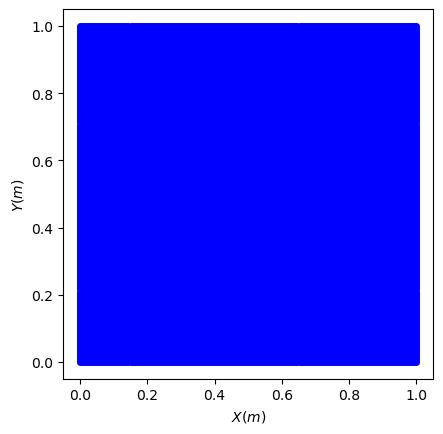

In [13]:
# Tracé du maillage
plt.figure()
# Tracé des lignes du maillage
plt.plot(np.ones(Nx+1)*x[0], y, '-',color='black')
plt.plot(np.ones(Nx+1)*x[Nx], y, '-',color='black')
for i in range(1,Nx+1):
    plt.plot(np.ones(Ny+1)*x[i]- dx/2, y, '-',color='black')
    plt.plot(x, np.ones(Ny+1)*y[0], '-',color='black')
    plt.plot(x, np.ones(Ny+1)*y[Ny], '-',color='black')
for j in range(1,Ny+1):
    plt.plot(x, np.ones(Ny+1)*y[j]- dy/2, '-',color='black')
    
# Tracé des centres de cellules
X,Y = np.meshgrid(x,y)
plt.plot(X, Y, 'o',markersize=4 ,color='blue')
plt.axis('scaled')
plt.xlabel(r'$X(m)$')
plt.ylabel(r'$Y(m)$')
plt.show()

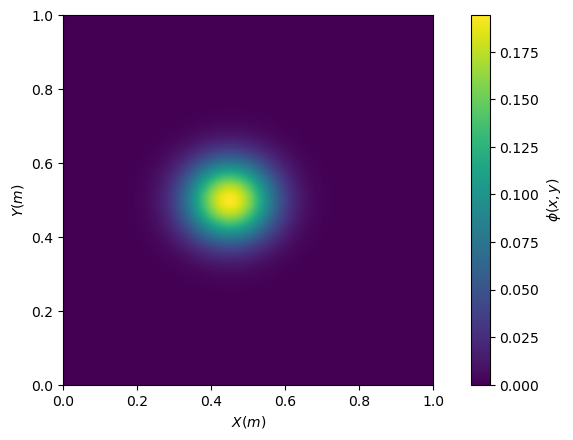

In [14]:
affichage(phi,-1,x,y)

## 2. Calcul de la solution et comparaison des résultats avec Star-CCM+

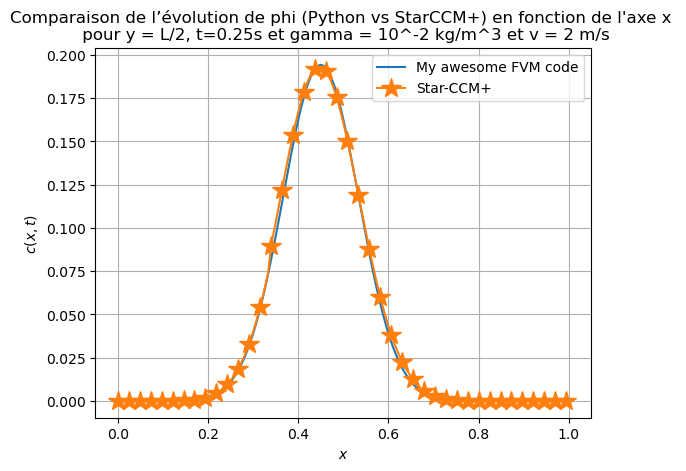

In [15]:
# Importation des données StarCCM+ depuis le fichier csv
data = np.loadtxt(r"Documents\XYPlot_gamma_0.001_v_1.csv",delimiter=",",skiprows=1)

# Comparaison des profils de concentration à y = L/2 et t = 0.25s
# entre le code Python et StarCCM+
plt.figure()
plt.plot(x,phi[:,int(Ny/2),-1],label='My awesome FVM code')
plt.plot(data[:,0],data[:,1],
'-*',markersize=15,markevery=4,label="Star-CCM+")
plt.xlabel("$x$")
plt.ylabel("$c(x,t)$")
plt.grid()
plt.legend()
plt.title("Comparaison de l’évolution de phi (Python vs StarCCM+) en fonction de l'axe x \n pour y = L/2, t=0.25s et gamma = 10^-2 kg/m^3 et v = 2 m/s")
plt.show()

In [16]:
phi1,x,y = resolution_phi (Lx, Ly, Nx, Ny, gamma, phi0, t, 2, V0, x0, y0, D)
phi2,x,y = resolution_phi (Lx, Ly, Nx, Ny, gamma, phi0, t, 0.5, V0, x0, y0, D)

0.249650399799204
0.249650399799204


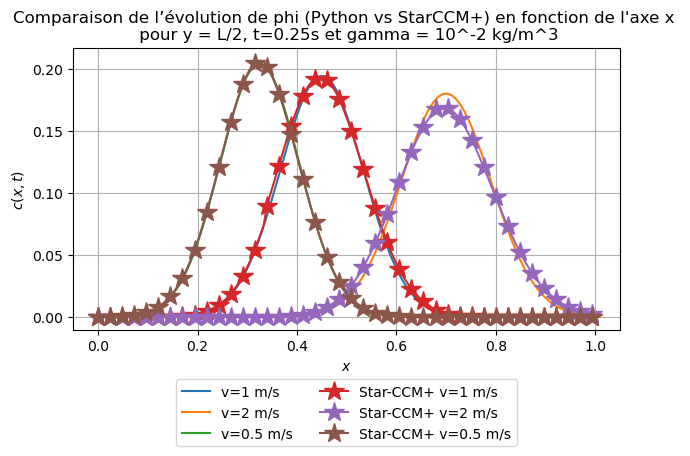

In [17]:
# Importation des données StarCCM+ depuis le fichier csv
data = np.loadtxt(r"W:\CFD_4A\CFD_4A\XYPlot_gamma_0.001_v_1.csv",delimiter=",",skiprows=1)
data1 = np.loadtxt(r"W:\CFD_4A\CFD_4A\XYPlot_gamma_0.001_v_2.csv",delimiter=",",skiprows=1)
data2 = np.loadtxt(r"W:\CFD_4A\CFD_4A\XYPlot_gamma_0.001_v_0.5.csv",delimiter=",",skiprows=1)

# Comparaison des profils de concentration à y = L/2 et t = 0.25s
# entre le code Python et StarCCM+
plt.figure()
plt.plot(x,phi[:,int(Ny/2),-1],label='v=1 m/s')
plt.plot(x,phi1[:,int(Ny/2),-1],label='v=2 m/s')
plt.plot(x,phi2[:,int(Ny/2),-1],label='v=0.5 m/s')
plt.plot(data[:,0],data[:,1],
'-*',markersize=15,markevery=4,label="Star-CCM+ v=1 m/s")
plt.plot(data1[:,0],data1[:,1],
'-*',markersize=15,markevery=4,label="Star-CCM+ v=2 m/s")
plt.plot(data2[:,0],data2[:,1],
'-*',markersize=15,markevery=4,label="Star-CCM+ v=0.5 m/s")
plt.title("Comparaison de l’évolution de phi (Python vs StarCCM+) en fonction de l'axe x \n pour y = L/2, t=0.25s et gamma = 10^-2 kg/m^3")
plt.xlabel("$x$")
plt.ylabel("$c(x,t)$")
plt.grid()
plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2)
plt.tight_layout()
plt.show()

In [18]:
phi1,x,y = resolution_phi (Lx, Ly, Nx, Ny, 2*10**(-3), phi0, t, U0, V0, x0, y0, D)
phi2,x,y = resolution_phi (Lx, Ly, Nx, Ny, 5*10**(-4), phi0, t, U0, V0, x0, y0, D)

0.2487539890279322
0.24850299401197606


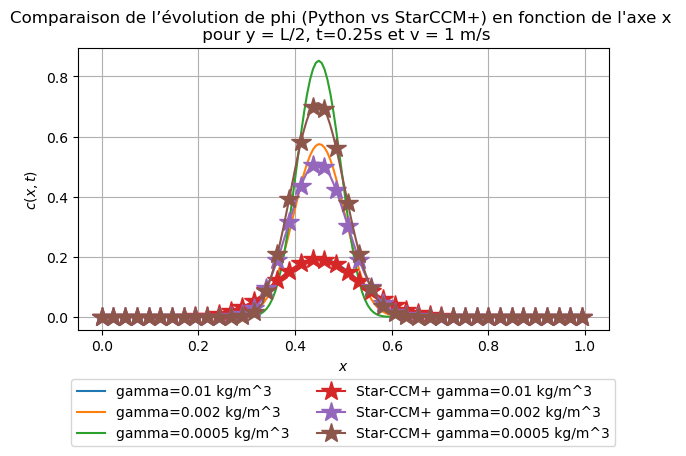

In [19]:
# Importation des données StarCCM+ depuis le fichier csv
data = np.loadtxt(r"W:\CFD_4A\CFD_4A\XYPlot_gamma_0.001_v_1.csv",delimiter=",",skiprows=1)
data1 = np.loadtxt(r"W:\CFD_4A\CFD_4A\XYPlot_gamma_0.002_v_1.csv",delimiter=",",skiprows=1)
data2 = np.loadtxt(r"W:\CFD_4A\CFD_4A\XYPlot_gamma_0.0005_v_1.csv",delimiter=",",skiprows=1)

# Comparaison des profils de concentration à y = L/2 et t = 0.25s
# entre le code Python et StarCCM+
plt.figure()
plt.plot(x,phi[:,int(Ny/2),-1],label='gamma=0.01 kg/m^3')
plt.plot(x,phi1[:,int(Ny/2),-1],label='gamma=0.002 kg/m^3')
plt.plot(x,phi2[:,int(Ny/2),-1],label='gamma=0.0005 kg/m^3')
plt.plot(data[:,0],data[:,1],
'-*',markersize=15,markevery=4,label="Star-CCM+ gamma=0.01 kg/m^3")
plt.plot(data1[:,0],data1[:,1],
'-*',markersize=15,markevery=4,label="Star-CCM+ gamma=0.002 kg/m^3")
plt.plot(data2[:,0],data2[:,1],
'-*',markersize=15,markevery=4,label="Star-CCM+ gamma=0.0005 kg/m^3")
plt.title("Comparaison de l’évolution de phi (Python vs StarCCM+) en fonction de l'axe x \n pour y = L/2, t=0.25s et v = 1 m/s")
plt.xlabel("$x$")
plt.ylabel("$c(x,t)$")
plt.grid()
plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2)
plt.tight_layout()
plt.show()